<a href="https://colab.research.google.com/github/annjgs/Fisica-Computacional/blob/Taller-8/Tarea_8_Matrices_Fourier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**TRANSFORMADA DE FOURIER**

#1

In [2]:
%%writefile ejercicio.cpp

#include <iostream>
#include <cmath>
#include <vector>
#include <complex>                  // Libreria para valores complejos


using namespace std;

// Función de producto matricial
vector<complex<double>> producto_matricial(const vector<vector<complex<double>>>& A,
                                       const vector<double>& B) {

    // Dimensiones de la matriz A
    int filas = A.size();
    int columnas = A[0].size();

    // Crear el resultado vacío
    vector<complex<double>> C(filas,0);

    // Verificar que las dimensiones sean compatibles
    if ( B.size() != columnas)
        cout << "La matriz y el vector no tienen dimensiones compatibles.\n";
    else
        // Calcular la multiplicacion matricial
        for (int i = 0; i < filas; ++i) {
            for (int j = 0; j < columnas; ++j) {
                C[i] += A[i][j] * B[j];
            }
        }
    return C;
}



const double PI = 3.14159265358979323846;
const int valorN = 62;
const complex<double> I(0,1);


//Funcion (Datos para hacer la transformada)
double F(double x) {
 return sin(x);
}



int main() {


//lista de valores de x
    int n = valorN;
    double inicio = 0;
    double fin = 2*PI;

    vector<double> x;

    double paso = (fin - inicio) / (n);

    for (int i = 0; i < n; i++) {
        x.push_back(inicio + i * paso);
    }

vector<double> real;
for (int i = 0; i < n; i++) {
    real.push_back(F(x[i]));
}



vector<vector<complex<double>>> matrizT(valorN, vector<complex<double>>(valorN,0));
for (int i = 0; i < valorN; ++i) {
            for (int j = 0; j < valorN; ++j) {
                matrizT[i][j] = exp((-2*PI*i*j*I)/double(valorN))  ;
            }
        }


  // Llamada a la función
  vector<complex<double>> matrizC = producto_matricial(matrizT, real);

    // Presentar el resultado
    cout << "Matriz resultado C:\n";

    for (int i = 0; i < matrizC.size(); ++i) {
            cout << matrizC[i] << " ";
        }
        cout << endl;

    return 0;

}

Writing ejercicio.cpp


In [ ]:
!g++ ejercicio.cpp -o ejercicio

In [ ]:
!./ejercicio > resultado.txt

#2


In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt

N = 64  # Número de muestras (potencia de 2 para FFT óptima)
t = np.arange(N)
# Señal: mezcla de dos frecuencias (f=4 y f=10)
xn = np.cos(2 * np.pi * t / N * 4) + 0.5 * np.sin(2 * np.pi * t / N * 10)


def dft_manual(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            # Fórmula de la matriz de rotación: e^(-j * 2*pi * k * n / N)
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)
    return X

# Calculamos
Xk_manual = dft_manual(xn)

Xk_fft = np.fft.fft(xn)


Exactitud comparada
Diferencia máxima entre Manual y FFT: 7.8777336492e-13
>> RESULTADO: Ambos métodos dan el mismo resultado (dentro del error de redondeo).


Eficiencia Comparada
Tiempo ejecución Manual (DFT O(N^2)): 0.00881934 segundos
Tiempo ejecución Automática (FFT):   0.00024080 segundos
La FFT fue 36.62 veces más rápida para N=64.


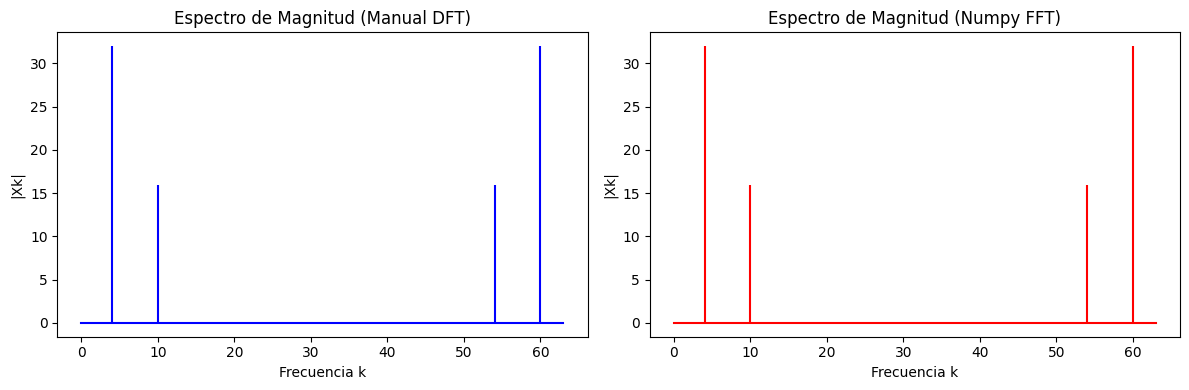

In [5]:
#comp
diff_max = np.max(np.abs(Xk_manual - Xk_fft))
print("Exactitud comparada")
print(f"Diferencia máxima entre Manual y FFT: {diff_max:.10e}")
if diff_max < 1e-10:
    print(">> RESULTADO: Ambos métodos dan el mismo resultado (dentro del error de redondeo).")
else:
    print(">> RESULTADO: Hay una discrepancia significativa.")

print("\n")


start_time = time.time()
_ = dft_manual(xn)
time_manual = time.time() - start_time

# Medimos tiempo FFT
start_time = time.time()
_ = np.fft.fft(xn)
time_fft = time.time() - start_time

print("Eficiencia Comparada")
print(f"Tiempo ejecución Manual (DFT O(N^2)): {time_manual:.8f} segundos")
print(f"Tiempo ejecución Automática (FFT):   {time_fft:.8f} segundos")
print(f"La FFT fue {time_manual / time_fft:.2f} veces más rápida para N={N}.")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.stem(np.arange(N), np.abs(Xk_manual), 'b', markerfmt=" ", basefmt="-b")
plt.title('Espectro de Magnitud (Manual DFT)')
plt.xlabel('Frecuencia k')
plt.ylabel('|Xk|')

plt.subplot(1, 2, 2)
plt.stem(np.arange(N), np.abs(Xk_fft), 'r', markerfmt=" ", basefmt="-r")
plt.title('Espectro de Magnitud (Numpy FFT)')
plt.xlabel('Frecuencia k')
plt.ylabel('|Xk|')
plt.tight_layout()
plt.show()